## Example Quadtree

In [1]:
# import necessary modules
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import logging

from hydromt_sfincs import SfincsModel
from hydromt_sfincs import utils

from hydromt._utils import log

log.initialize_logging()
log.set_log_level(log_level = 1)

2025-10-29 11:03:24,431 - hydromt - log - INFO - HydroMT version: 1.3.0-rc3
2025-10-29 11:03:25,080 - hydromt - log - INFO - HydroMT version: 1.3.0-rc3


#### Start with a regular grid model

In [2]:
# Initialize SfincsModel Python class with the artifact data catalog which contains publically available data for North Italy
# we overwrite (mode='w+') the existing model in the root directory if it exists
sf = SfincsModel(data_libs=["artifact_data"], root="test_regular", mode="w+")

2025-10-29 11:03:30,629 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2025-10-29 11:03:30,630 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\asselt\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2025-10-29 11:03:31,312 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0.dev0).
2025-10-29 11:03:31,313 - hydromt.model.model - model - WARNING - No region component found in components.


In [3]:
# Specify an input dictionary with the grid settings x0,y0,dx,dy,nmax,mmax,rotation and epsg code.
# create SFINCS model with regular grid and characteristics of the input dictionary:
sf.grid.create(
    x0=318650,
    y0=5040000,
    dx=50.0,
    dy=50.0,
    nmax=107,
    mmax=250,
    rotation=27,
    epsg=32633,
)

2025-10-29 11:03:37,039 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 8 attributes in model config.


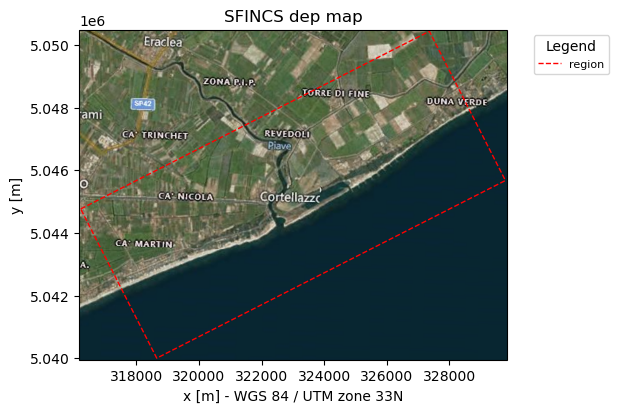

In [4]:
# show the model grid outline
# sf.region.boundary.plot(figsize=(6,6))
_ = sf.plot_basemap(plot_region=True, bmap="sat", zoomlevel=12)

In [5]:
# now create a geodataframe that covers a part of the model grid
elevation_sets = [{"elevation": "merit_hydro", "zmin": 0.001}, {"elevation": "gebco"}]

# Add depth information to modelgrid based on these chosen datasets
sf.elevation.create(elevation_sets=elevation_sets)
sf.mask.create_active(zmin=-5)
sf.mask.create_boundary(btype="waterlevel", zmax=-5, reset_bounds=True)

2025-10-29 11:03:42,987 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:03:43,073 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:03:43,552 - hydromt.hydromt_sfincs.components.grid.mask - mask - INFO - 3 gaps outside valid elevation range < 10.0 km2.
2025-10-29 11:03:43,557 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 2 attributes in model config.
2025-10-29 11:03:43,582 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


In [6]:
# derive river from hydrography data based on a minimum river length (river_len)
# and minimum upstream area (river_upa)

sf.rivers.create_river_inflow(
    hydrography="merit_hydro", river_len=1000, river_upa=50, keep_rivers_geom=True
)

2025-10-29 11:03:44,826 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif


Create a 200m buffer around the river

In [7]:
gdf_riv = sf.rivers.data.copy()
gdf_riv_buf = gdf_riv.assign(geometry=gdf_riv.buffer(200))
gdf_riv_buf["refinement_level"] = 2

Create a 500m buffer around the coastline

In [ ]:
gdf_osm = sf.data_catalog.get_geodataframe("osm_coastlines", bbox=sf.bbox, buffer=0)

# convert polygon to line
gdf_osm_line = gdf_osm.to_crs(sf.crs).boundary

# add a buffer to the line of 500m
gdf_osm_buf = gdf_osm_line.buffer(500)

# clip to model extent (why again needed?)
gdf_osm_buf = gdf_osm_buf.intersection(sf.region.geometry)

2025-10-29 11:03:57,153 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading osm_coastlines GeoDataFrame data from C:\Users\asselt\.hydromt\artifact_data\latest\osm_coastlines.gpkg


<GeoAxes: title={'center': 'SFINCS dep map'}, xlabel='x [m] - WGS 84 / UTM zone 33N', ylabel='y [m]'>

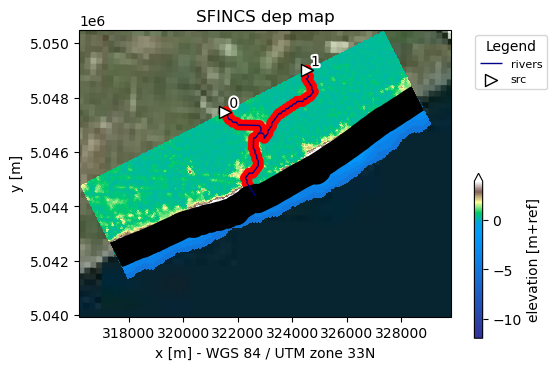

In [10]:
# Make a plot of model
# note the src points and derived river network
fig, ax = sf.plot_basemap(variable="dep", plot_bounds=False, bmap="sat")

# plot gdf_riv on top
gdf_riv_buf.plot(ax=ax, color="red", linewidth=0.5)
gdf_osm_buf.plot(ax=ax, color="black", linewidth=0.5)

#### Continue with building a QuadTree model that is refined along the river and coast

In [11]:
sf_qt = SfincsModel(
    data_libs=["artifact_data"],
    root="test_quadtree",
    mode="w+",
)

2025-10-29 11:04:40,056 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2025-10-29 11:04:40,057 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\asselt\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2025-10-29 11:04:40,675 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0.dev0).
2025-10-29 11:04:40,676 - hydromt.model.model - model - WARNING - No region component found in components.


Generate topobathy on the quadtree grid

In [12]:
gdf_refinement = gpd.GeoDataFrame(
    {"refinement_level": [1, 2]},
    geometry=[
        gdf_osm_buf.unary_union,
        gdf_riv_buf.unary_union,
    ],
    crs=sf.crs,
)

# set first row zmin to 0
gdf_refinement.loc[0, "zmin"] = 0
gdf_refinement

sf_qt.quadtree_grid.create(
    x0=318650,
    y0=5040000,
    dx=50.0,
    dy=50.0,
    nmax=107,
    mmax=250,
    rotation=27,
    epsg=32633,
    refinement_polygons=gdf_refinement,
    elevation_sets=[
        {"elevation": "merit_hydro", "zmin": 0.001},
        {"elevation": "gebco"},
    ],
)

2025-10-29 11:05:01,966 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:05:01,983 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:05:02,017 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:05:02,045 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
Refining ...
Time elapsed : 1.1239089965820312 s
Finding neighbors ...
Time elapsed : 0.018999814987182617 s
Setting neighbors left and below ...
Time elapsed : 0.09136128425598145 s
Getting uv points ...
Time elapsed 

Or create a model straight from a polygon! No need to determine grid parameters and coordinate reference 

In [ ]:
# sf_qt.quadtree_grid.create_from_region(
#     region={"geom": sf.region},  # area that needs to be covered by the grid
#     res=200,  # set resolution
#     rotated=True,  # when True, rotation is determined to minimize the grid extent
#     refinement_polygons=gdf_refinement,
# )

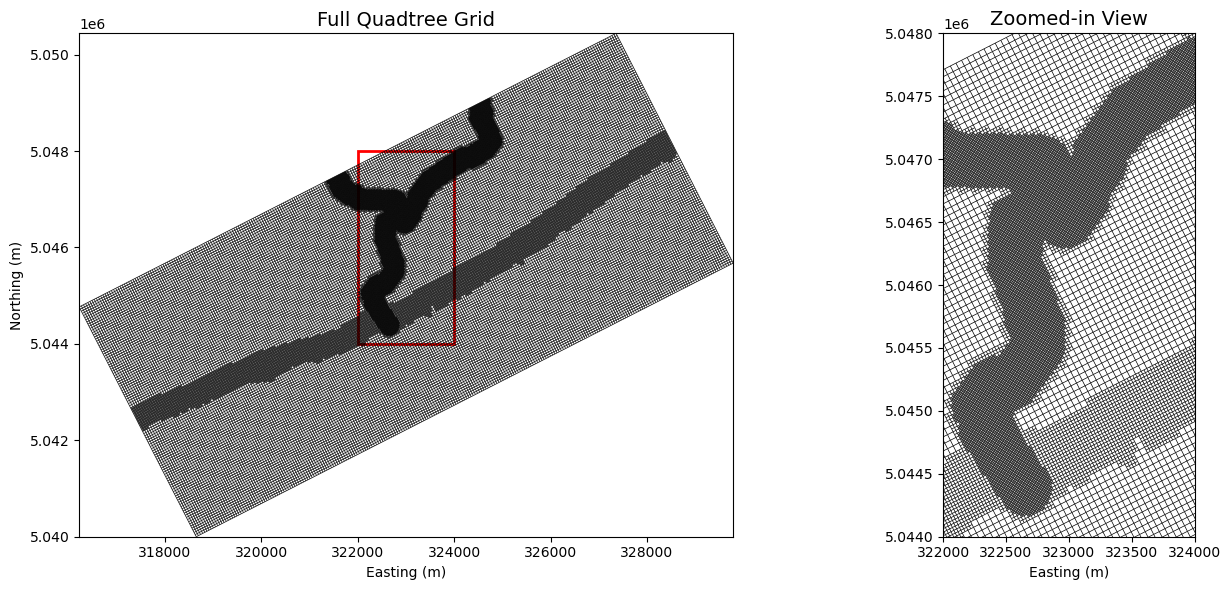

In [34]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Create figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the quadtree grid lines on both subplots
sf_qt.quadtree_grid.data["level"].ugrid.plot.line(ax=ax1, color="black", linewidth=0.5)
sf_qt.quadtree_grid.data["level"].ugrid.plot.line(ax=ax2, color="black", linewidth=0.5)

# Define zoomed-in extent
zoom_xlim = [322000, 324000]
zoom_ylim = [5044000, 5048000]

# Apply zoom on second plot
ax2.set_xlim(zoom_xlim)
ax2.set_ylim(zoom_ylim)

# Make both axes equal aspect
ax1.set_aspect("equal")
ax2.set_aspect("equal")

# Add red rectangle to indicate zoom region on left plot
rect = Rectangle(
    (zoom_xlim[0], zoom_ylim[0]),
    zoom_xlim[1] - zoom_xlim[0],
    zoom_ylim[1] - zoom_ylim[0],
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
ax1.add_patch(rect)

# Add nice titles and labels
ax1.set_title("Full Quadtree Grid", fontsize=14)
ax2.set_title("Zoomed-in View", fontsize=14)
ax1.set_xlabel("Easting (m)")
ax1.set_ylabel("Northing (m)")
ax2.set_xlabel("Easting (m)")

# Clean layout and show
plt.tight_layout()
plt.show()


In [40]:
elevation_sets = [{"elevation": "merit_hydro", "zmin": 0.001}, {"elevation": "gebco"}]

sf_qt.quadtree_elevation.create(elevation_sets=elevation_sets, partition_by_level=False)

2025-10-29 11:21:04,913 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:21:04,950 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:21:04,980 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:21:05,008 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:21:05,039 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 

(<Figure size 600x329.861 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS z map'}, xlabel='x [m] - WGS 84 / UTM zone 33N', ylabel='y [m]'>)

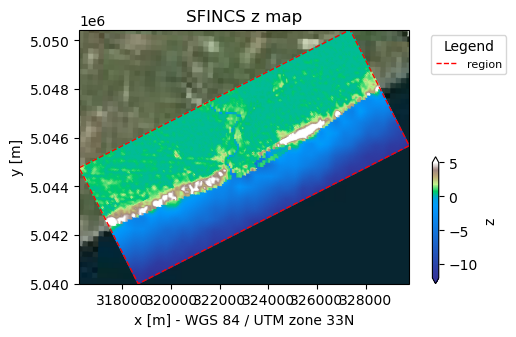

In [41]:
sf_qt.plot_basemap(variable="z", plot_region=True, plot_bounds=False, bmap="sat")
# sf_qt.quadtree.data["dep"].ugrid.plot()

In [42]:
sf_qt.quadtree_elevation.set_bathymetry(elevation_sets=elevation_sets)

2025-10-29 11:21:17,687 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif


2025-10-29 11:21:17,725 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:21:17,753 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:21:17,781 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:21:17,807 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:21:17,836 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:21:17,849 - hydromt.

(<Figure size 600x329.861 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS z map'}, xlabel='x [m] - WGS 84 / UTM zone 33N', ylabel='y [m]'>)

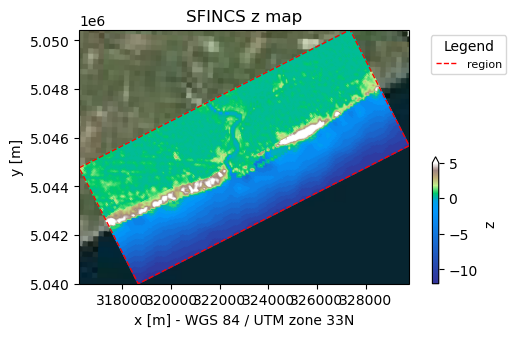

In [43]:
sf_qt.plot_basemap(variable="z", plot_region=True, plot_bounds=False, bmap="sat")

Continue with the mask for the QuadTree grid; we aim to have the same active extent as the regular grid in different ways:
- Based on elevation
- By using an include polygon

In [44]:
# add the gdf mask_include to gdf_refinement as combined gdf
mask_include = gpd.GeoDataFrame(
    pd.concat([sf.region, gdf_refinement], ignore_index=True)
)

# create a new buffer that most includes the open boundary
gdf_osm_buf2 = gdf_osm_buf.buffer(2000, cap_style=3)
open_include = gpd.GeoDataFrame(geometry=gdf_osm_buf2, crs=sf_qt.crs)

In [45]:
# new code, splitted into two steps
sf_qt.quadtree_mask.create_active(
    include_polygon=mask_include,
    all_touched=False,
)
sf_qt.quadtree_mask.create_boundary(
    btype="waterlevel",
    include_polygon=open_include,
    zmax=-3,
    reset_bounds=True,
)

2025-10-29 11:35:50,480 - hydromt.hydromt_sfincs.components.quadtree.quadtree_mask - quadtree_mask - INFO - Building mask ...
2025-10-29 11:35:50,481 - hydromt.hydromt_sfincs.components.quadtree.quadtree_mask - quadtree_mask - INFO - Build new mask for: sfincs ...


(<Figure size 600x329.861 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS mask map'}, xlabel='x [m] - WGS 84 / UTM zone 33N', ylabel='y [m]'>)

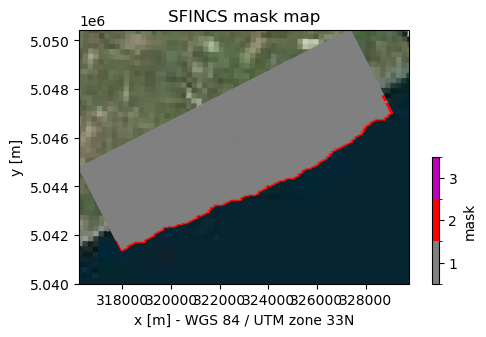

In [46]:
# plot the mask
sf_qt.plot_basemap(variable="mask", plot_bounds=False, bmap="sat")

In [47]:
sf_qt.quadtree_mask.build(
    include_polygon=mask_include,
    open_boundary_polygon=open_include,
    open_boundary_zmax=-3,
)

In [ ]:
# plot the mask
sf_qt.plot_basemap(variable="mask", plot_bounds=False, bmap="sat")

### Now create a subgrid table for this model

In [49]:
sf_qt.quadtree_subgrid.create(
    bathymetry_sets=elevation_sets,
    nr_subgrid_pixels=6,
    write_dep_tif=True,
    write_man_tif=True,
)

2025-10-29 11:37:12,686 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:37:12,725 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:37:12,757 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 11:37:12,789 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gebco.tif
2025-10-29 11:37:12,822 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\merit_hydro\{variable}.tif
2025-10-29 

### Now add some random waterlevel timeseries

In [50]:
# x&y-locations in same coordinate reference system as the grid:
x = [319526, 329195]
y = [5041108, 5046243]

# add to Geopandas dataframe as needed by HydroMT
pnts = gpd.points_from_xy(x, y)
index = [1, 2]  # NOTE that the index should start at one
bnd = gpd.GeoDataFrame(index=index, geometry=pnts, crs=sf.crs)

# In this case we will provide 3 values (periods=3) between the start (tstart=20100201 000000) and the end (tstop=20100201 120000) of the simulation:
time = pd.date_range(
    start=sf.config.get("tstart"),
    end=sf.config.get("tstop"),
    periods=3,
)

# add some water levels
bzs = [[0, 0.25], [0.75, 1.0], [0, 0.25]]

bzspd = pd.DataFrame(index=time, columns=index, data=bzs)

# Actually add it to the SFINCS model class:
sf_qt.water_level.create(timeseries=bzspd, locations=bnd)

### Write the model

In [51]:
sf_qt.config.set("tspinup", 3600)
sf_qt.write()

2025-10-29 11:37:44,265 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - No subgrid table available to write.


## Run and read results, make plots and animation

In [52]:
"""
HydroMT-SFINCS utilities functions
"""

import os
import subprocess
import sys
from os.path import join
from typing import Union, Optional
from pathlib import Path


def run_sfincs(
    model_root: Union[Path, str],
    sfincs_exe: Optional[Union[Path, str]] = None,
    vm: Optional[str] = None,
    docker_tag: str = "latest",
    verbose: bool = True,
) -> None:
    """
    Run the SFINCS model.

    Either sfincs_exe or vm must be specified.
    If both are specified, sfincs_exe is used.

    Parameters
    ----------
    model_root : Path, str
        The root directory of the model.
    sfincs_exe : Path, str, optional
        The path to the SFINCS executable, by default None.
    vm : str, optional
        The virtual machine to use, either 'docker' or 'singularity', by default None.
    docker_tag : str, optional
        The tag of the docker image to use, by default 'latest'.
        See https://hub.docker.com/r/deltares/sfincs-cpu/tags for available tags.
        Only used if vm is not None.
    verbose : bool, optional
        If True, print the output of the SFINCS model to the console, by default True.
    """
    # check model_root
    if not os.path.isabs(model_root):
        model_root = os.path.abspath(model_root)
    model_root = str(model_root)
    sfincs_inp = join(model_root, "sfincs.inp")
    if not os.path.exists(sfincs_inp):
        raise ValueError(f"SFINCS inp file does not exist: {sfincs_inp}")

    # set command to run depending on OS and VM
    if sfincs_exe is not None and sys.platform == "win32":
        if not os.path.isabs(sfincs_exe):
            sfincs_exe = os.path.abspath(sfincs_exe)
        if not os.path.exists(sfincs_exe):
            raise ValueError(f"sfince_exe path does not exist: {sfincs_exe}")
        cmd = str(sfincs_exe)
    elif vm is not None:
        if vm == "docker":
            cmd = f"docker run -v {model_root}://data deltares/sfincs-cpu:{docker_tag}"
        elif vm == "singularity":
            cmd = f"singularity run -B{model_root}:/data --nv docker://deltares/sfincs-cpu:{docker_tag}"
        else:
            raise NotImplementedError(
                f"{vm} not supported, use 'docker' or 'singularity'"
            )
    else:
        if sys.platform == "win32":
            raise ValueError("sfince_exe must be specified for Windows")
        else:
            raise ValueError("vm must be specified for Linux or macOS")
    if verbose:
        print(f">> {cmd}\n")

    # run & write log file
    with subprocess.Popen(
        cmd,
        cwd=model_root,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        universal_newlines=True,  # get string output instead of bytes
    ) as proc:
        with open(join(model_root, "sfincs_log.txt"), "w") as f:
            for line in proc.stdout:
                if verbose:
                    print(line.rstrip("\n"))
                f.write(line)
            for line in proc.stderr:
                if verbose:
                    print(line.rstrip("\n"))
                f.write(line)
        proc.wait()
        return_code = proc.returncode

    # check return code
    if vm is not None and return_code == 127:
        raise RuntimeError(
            f"{vm} not found. Make sure it is installed, running and added to PATH."
        )
    elif return_code != 0:
        raise RuntimeError(f"SFINCS run failed with return code {return_code}")

    return None

In [53]:
sfincs_exe = r"p:\11202255-sfincs\executables\SFINCS_2025_branches\sfincs_exe_main_22_07_2025\sfincs.exe"

run_sfincs(model_root=sf_qt.root.path, sfincs_exe=sfincs_exe)

>> p:\11202255-sfincs\executables\SFINCS_2025_branches\sfincs_exe_main_22_07_2025\sfincs.exe


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@.....::.
    .:::~@@.:...:.

In [ ]:
# read results
# sf_qt.root.set(path=sf_qt.root.path.resolve(),mode="r")
sf_qt.output.read()

In [ ]:
# now plot the bed levels
zb = sf_qt.output.data["zb"]
sf_qt.plot_basemap(variable=zb, plot_bounds=False, bmap="sat", cmap="terrain", vmax=5)

In [ ]:
zsmax = sf_qt.output.data["zsmax"].max(dim="timemax")
sf_qt.plot_basemap(variable=zsmax, plot_bounds=False, bmap="sat", cmap="viridis")

In [ ]:
# plot rough estimation of water depth
h = zsmax - zb
# only plot where water depth > 0.1
h = h.where(h > 0.1)
# add label to h
h.name = "Water depth"

sf_qt.plot_basemap(variable=h, plot_bounds=False, bmap="sat", cmap="viridis")

In [ ]:
# create zs plot and save to mod.root/figs/sfincs_zs.mp4
# requires ffmpeg install with "conda install ffmpeg -c conda-forge"
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation

step = 1  # one frame every <step> dtout
cbar_kwargs = {"shrink": 0.6, "anchor": (0, 0)}
da_zs = sf_qt.results["zs"]


def update_plot(i, da_zs, cax_zs):
    da_zsi = da_zs.isel(time=i)
    t = da_zsi.time.dt.strftime("%d-%B-%Y %H:%M:%S").item()
    ax.set_title(f"SFINCS water level {t}")
    cax_zs.set_array(da_zsi.values.ravel())


fig, ax = sf_qt.plot_basemap(
    ax=ax, variable="", plot_bounds=False, bmap="sat", zoomlevel=13, figsize=(11, 7)
)
cax_zs = da_zs.isel(time=0).ugrid.plot(
    ax=ax, vmin=0, vmax=3, cmap=plt.cm.viridis, zorder=1, cbar_kwargs=cbar_kwargs
)
plt.close()  # to prevent double plot

ani = animation.FuncAnimation(
    fig,
    update_plot,
    frames=np.arange(0, da_zs.time.size, step),
    interval=250,  # ms between frames
    fargs=(
        da_zs,
        cax_zs,
    ),
)

# to save to mp4
# ani.save(join(mod.root, 'figs', 'sfincs_h.mp4'), fps=4, dpi=200)

# to show in notebook:
from IPython.display import HTML

HTML(ani.to_html5_video())

## Now some snapwave functionalities

In [ ]:
%matplotlib inline
sf_qt.quadtree_mask.create(model="snapwave", zmin=-20, zmax=0.2)

sf_qt.plot_basemap(variable="snapwave_msk", plot_bounds=False, bmap="sat")

Try situation where we want to directly copy the SFINCS mask to SnapWave:

In [ ]:
gdf_osm_buf

In [ ]:
# %matplotlib qt
%matplotlib inline

uda = sf_qt.quadtree_mask.set_bounds(
    model="snapwave",
    btype="waves",
    zmax=-4,  # set all cells with water depth > 4m as wave boundaries
    exclude_mask=gdf_refinement,  # exclude the cells close to the coast
    connectivity=4,
    reset_bounds=True,
)
uda
sf_qt.plot_basemap(variable="snapwave_msk", plot_bounds=False, bmap="sat")

## Add some more boundary conditions

In [ ]:
# # We now use the previously created src discharge points for the regular model
# gdf = sf.forcing["dis"].vector.to_gdf()

# # make up some discharge data
# index = sf.forcing["dis"].index
# dis = np.array([[2.0, 1.0], [5.0, 2.0], [2.0, 1.0]])
# dispd = pd.DataFrame(index=time, columns=index, data=dis)

# # now we call the function setup_discharge_forcing, which adds the discharge forcing to the src points
# sf_qt.setup_discharge_forcing(timeseries=dispd, locations=gdf)

# # # NOTE: the discharge forcing data is now stored in the sf.forcing dictionary
# sf_qt.forcing.keys()

## And save everything we build sofar

In [ ]:
# this is needed for stability?
# TODO check wheterh we have a stable solution in the end; seems to be unstable at the jumps in resolution
sf_qt.config["tspinup"] = 3600
sf_qt.config["alpha"] = 0.4

In [ ]:
sf_qt.config[
    "snapwave_bndfile"
] = "input_locations_ERA5_tmp.bnd"  # org of OuterBanks is in UTM 18N not 17N!
sf_qt.config["snapwave_bhsfile"] = "bhs_ERA5_tmp.bhs"
sf_qt.config["snapwave_btpfile"] = "btp_ERA5_tmp.btp"
sf_qt.config["snapwave_bwdfile"] = "mwd_ERA5_tmp.mwd"
sf_qt.config["snapwave_bdsfile"] = "bds_ERA5_tmp.bds"

In [ ]:
sf_qt.write()

## Comparison between old and new, more efficient, code for the mask

In [ ]:
# old, original code, uncomment to compare
# sf_qt.quadtree.setup_mask(include_polygon=mask_include, open_boundary_polygon=open_include, open_boundary_zmax=-3)

In [ ]:
# plot the difference between the mask (original code) and the msk (new code)
# NOTE with all_touched=True, there is a small difference
# (sf_qt.quadtree.data["mask"]-sf_qt.quadtree.data["msk"]).ugrid.plot()

In [ ]:
# NOTE even in the new methods, we lose performance through the SfincsModel, I expect this to come from the data_catalog that parses the geodataframes
# this can be improved by directly using the geopandas geodataframes in the underlying method, e.g.:
# sf_qt.quadtree.setup_mask_active(gdf_include=mask_include, all_touched=False)

In [ ]:
# drop the mask variable from the quadtree data
# sf_qt.quadtree.data = sf_qt.quadtree.data.drop("mask")

In [ ]:
# sf_qt.quadtree.setup_mask_active(model="snapwave", gdf_include= mask_include)#, gdf_exclude= new_exclude)#, gdf_include= include

# sf_qt.quadtree.data["snapwave_msk"].ugrid.plot()
# plt.axis('equal')